## **Financial Fraud Detection: Modeling**

insert abstract similar to main README file

In [1]:
# Importing sys to ensure proper environment setup
import sys

!{sys.executable} -m pip install lightgbm

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing lightgbm as gradient boosting framework for tree based learning algorightms
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import lightgbm as lgb
import os # possibly remove
from pathlib import Path
from scipy.stats import multivariate_normal, norm, trim_mean, zscore
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn items for model training & testing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_curve, precision_score, classification_report,
    confusion_matrix, mean_absolute_error, accuracy_score, recall_score, f1_score, 
    roc_curve, roc_auc_score, precision_recall_fscore_support)

%matplotlib inline

sns.set(style="whitegrid", palette="muted", font_scale=1.25)

print("Setup Complete")

Setup Complete


In [3]:
# Dealing with plathform-specific issues that may cause errors
# For systems that use backslash (\) characters instead of forward (/) slash
from pathlib import Path, PureWindowsPath

# Explicity noting path as being in Windows format so I can use forward slash
clean = PureWindowsPath("C:\\Users\\Winni\\fin-fraud-detect\\Data\\cleaned.csv")

# Convert path to the correct format
file_path = Path(clean)

# Loading data as a DataFrame
df_clean = pd.read_csv(file_path) 

print("Shape:", df_clean.shape)
print("Missing values:\n", df_clean.isnull().sum())
print("\nPreview:\n", df_clean.head())

# Using head() function to display the first five rows of the data
print("Heads")
print(df_clean.head())

print()

# Using tail() function to display the last five rows of the data
print("Tails")
print(df_clean.tail())

Shape: (6362620, 11)
Missing values:
 step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
type_CASH_OUT     0
type_DEBIT        0
type_PAYMENT      0
type_TRANSFER     0
dtype: int64

Preview:
    step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1  9.194276      12.044359       11.984786        0.000000   
1     1  7.531166       9.964112        9.872292        0.000000   
2     1  5.204007       5.204007        0.000000        0.000000   
3     1  5.204007       5.204007        0.000000        9.960954   
4     1  9.364703      10.634773       10.305174        0.000000   

   newbalanceDest  isFraud  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
0             0.0        0       0.000000         0.0      0.693147   
1             0.0        0       0.000000         0.0      0.693147   
2             0.0        1       0.000000         0.0      0.000000   
3             0.0        

---
### **Diagnostic Checks & Feature Engineering**

In [4]:
# Checking raw dataframe
print("Columns:", df_clean.columns.tolist())
print("\nisFraud value counts:")
print(df_clean['isFraud'].value_counts())
print("\nisFraud dtype:", df_clean['isFraud'].dtype)

Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

isFraud value counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

isFraud dtype: int64


In [5]:
df1 = df_clean

# df1 features for supervised machine learning
features = ["amount", "step", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT", "type_TRANSFER"]
X = df1[features]
y = df1["isFraud"]

In [6]:
# Checking X and y as they exist right before the split
print("y unique values:", y.unique())
print("y dtype:", y.dtype)
print("y value counts:")
print(y.value_counts())

y unique values: [0 1]
y dtype: int64
y value counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Checking class distributions before training
print("Train class counts:", y_train.value_counts())
print("Test class counts: ", y_test.value_counts())

# Check X_train & y_train shapes and types
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_train unique:", y_train.unique())
print("y_train dtype:", y_train.dtype)
print("\nAny NaN in X_train:", X_train.isnull().sum().sum())
print("Any NaN in y_train:", y_train.isnull().sum())

Train class counts: isFraud
0    5083526
1       6570
Name: count, dtype: int64
Test class counts:  isFraud
0    1270881
1       1643
Name: count, dtype: int64
X_train shape: (5090096, 6)
y_train shape: (5090096,)
y_train unique: [0 1]
y_train dtype: int64

Any NaN in X_train: 0
Any NaN in y_train: 0


---
### **LightGBM trained with imbalance handling**

Class 0 (non-fraud): 5083526
Class 1 (fraud): 6570
scale_pos_weight: 773.75
[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
Optimal Threshold (F1): 1.0000
Optimal Threshold (Recall-focused): 0.5000

--- LightGBM (F1-optimized) ---
              precision    recall  f1-score   support

           0       1.00      0.86      0.92   1270881
           1       0.01      0.73      0.01      1643

    accuracy                           0.86   1272524
   macro avg       0.50      0.79      0.47   1272524
weighted avg       1.00      0.86      0.92   1272524


--- LightGBM (Recall-optimized) ---
              precision    recall  f1-score   support

           0       1.00      0.84      0.91   1270881
           

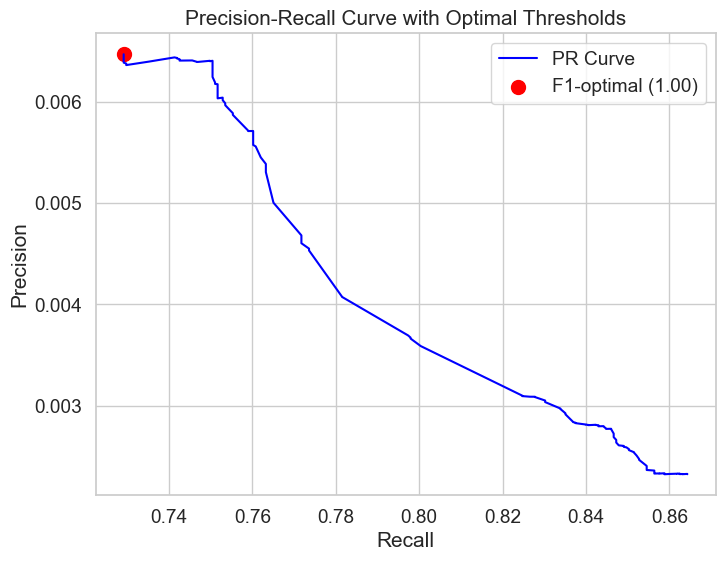

In [9]:
# Class balance check
n_class0 = (y_train == 0.0).sum()
n_class1 = (y_train == 1).sum()

print(f"Class 0 (non-fraud): {n_class0}")
print(f"Class 1 (fraud): {n_class1}")

# Safety check
if n_class0 == 0 or n_class1 == 0:
    print(f"WARNING: Only one class present in y_train — check data pipeline!")
    print("Falling back to scale_pos_weight=1 (no class balancing)")
    spw = 1.0
else:
    spw = n_class0 / n_class1   # typically majority/minority for fraud detection
    print(f"scale_pos_weight: {spw:.2f}")

# Training model
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.05,
    scale_pos_weight=spw,
    force_row_wise=True,  # removes LightGBM warning
    random_state=42
)

lgb_model.fit(X_train, y_train)

#Get predicted probabilities
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

#Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgb)

precision = precision[:-1]
recall = recall[:-1]

valid = (thresholds > 0) & (thresholds < 1)
precision, recall, thresholds = precision[valid], recall[valid], thresholds[valid]

#Option A: Maximize F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds[optimal_idx_f1]

#Option B: Maximize Recall with Precision > 0.2
mask = precision > 0.2
if mask.any():
    recall_threshold_idx = np.argmax(recall[mask])
    optimal_threshold_recall = thresholds[mask][recall_threshold_idx]
else:
    optimal_threshold_recall = 0.5  # fallback

print(f"Optimal Threshold (F1): {optimal_threshold_f1:.4f}")
print(f"Optimal Threshold (Recall-focused): {optimal_threshold_recall:.4f}")

# --- Predictions & Reports ---
y_pred_lgb_f1 = (y_prob_lgb >= optimal_threshold_f1).astype(int)
y_pred_lgb_recall = (y_prob_lgb >= optimal_threshold_recall).astype(int)

print("\n--- LightGBM (F1-optimized) ---")
print(classification_report(y_test, y_pred_lgb_f1, zero_division=0))

print("\n--- LightGBM (Recall-optimized) ---")
print(classification_report(y_test, y_pred_lgb_recall, zero_division=0))

#Plot Precision-Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="PR Curve", color="blue")

#Mark optimal thresholds
plt.scatter(recall[optimal_idx_f1], precision[optimal_idx_f1], 
            color="red", label=f"F1-optimal ({optimal_threshold_f1:.2f})", s=100)
if mask.any():
    plt.scatter(recall[mask][recall_threshold_idx], precision[mask][recall_threshold_idx], 
                color="green", label=f"Recall-optimal ({optimal_threshold_recall:.2f})", s=100)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Thresholds")
plt.legend()
plt.grid(True)
plt.show()

---
### **Random Forest baseline**

In [10]:
# Random Forest Classifier and Fraud Risk Score Plot

#Train Random Forest with class weights to handle imbalance
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced_subsample',
    random_state=42
)
rf_model.fit(X_train, y_train)

#Predict probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

#Find optimal threshold based on F1 score
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
optimal_threshold = thresholds[np.argmax(f1_scores[:-1])]  # exclude last element

#Apply optimal threshold
y_pred = (y_prob >= optimal_threshold).astype(int)

#Report performance
print("Optimal Threshold:", optimal_threshold)
print(classification_report(y_test, y_pred))

#Create df_test with fraud risk score
df_test = pd.DataFrame({
    "fraud_risk_score": y_prob,
    "isFraud": y_test.reset_index(drop=True)
})

#Plot KDE of risk scores
plt.figure(figsize=(12,6))
sns.kdeplot(df_test[df_test['isFraud']==0]['fraud_risk_score'], label="Non-Fraud", fill=True)
sns.kdeplot(df_test[df_test['isFraud']==1]['fraud_risk_score'], label="Fraud", fill=True, color="red")

#Add vertical line for optimal threshold
plt.axvline(optimal_threshold, color="black", linestyle="--", linewidth=2, label=f"Optimal Threshold = {optimal_threshold:.2f}")

plt.title("Fraud Risk Score (Supervised Model)")
plt.xlabel("Predicted Probability of Fraud")
plt.ylabel("Density")
plt.legend()
plt.show()

KeyboardInterrupt: 

---
### **Gradient Boosting baseline**

In [11]:
class DecisionTree():
    def __init__(self, x, y, idxs = None, min_leaf=2):
        if idxs is None: idxs=np.arange(len(y))
        self.x,self.y,self.idxs,self.min_leaf = x,y,idxs,min_leaf
        self.n,self.c = len(idxs), x.shape[1]
        self.val = np.mean(y[idxs])
        self.score = float('inf')
        self.find_varsplit()
        
    def find_varsplit(self):
        for i in range(self.c): self.find_better_split(i)
        if self.score == float('inf'): return
        x = self.split_col
        lhs = np.nonzero(x<=self.split)[0]
        rhs = np.nonzero(x>self.split)[0]
        self.lhs = DecisionTree(self.x, self.y, self.idxs[lhs])
        self.rhs = DecisionTree(self.x, self.y, self.idxs[rhs])

    def find_better_split(self, var_idx):
        x,y = self.x.values[self.idxs,var_idx], self.y[self.idxs]
        sort_idx = np.argsort(x)
        sort_y,sort_x = y[sort_idx], x[sort_idx]
        rhs_cnt,rhs_sum,rhs_sum2 = self.n, sort_y.sum(), (sort_y**2).sum()
        lhs_cnt,lhs_sum,lhs_sum2 = 0,0.,0.

        for i in range(0,self.n-self.min_leaf-1):
            xi,yi = sort_x[i],sort_y[i]
            lhs_cnt += 1; rhs_cnt -= 1
            lhs_sum += yi; rhs_sum -= yi
            lhs_sum2 += yi**2; rhs_sum2 -= yi**2
            if i<self.min_leaf or xi==sort_x[i+1]:
                continue

            lhs_std = std_agg(lhs_cnt, lhs_sum, lhs_sum2)
            rhs_std = std_agg(rhs_cnt, rhs_sum, rhs_sum2)
            curr_score = lhs_std*lhs_cnt + rhs_std*rhs_cnt
            if curr_score<self.score: 
                self.var_idx,self.score,self.split = var_idx,curr_score,xi

    @property
    def split_name(self): return self.x.columns[self.var_idx]
    
    @property
    def split_col(self): return self.x.values[self.idxs,self.var_idx]

    @property
    def is_leaf(self): return self.score == float('inf')
    
    def __repr__(self):
        s = f'n: {self.n}; val:{self.val}'
        if not self.is_leaf:
            s += f'; score:{self.score}; split:{self.split}; var:{self.split_name}'
        return s

    def predict(self, x):
        return np.array([self.predict_row(xi) for xi in x])

    def predict_row(self, xi):
        if self.is_leaf: return self.val
        t = self.lhs if xi[self.var_idx]<=self.split else self.rhs
        return t.predict_row(xi)

In [12]:
# Setting up Gradient Boosting (aka Decision Trees in a loop)
def std_agg(cnt, s1, s2): return math.sqrt((s2/cnt) - (s1/cnt)**2)

xi = x # initialization of input
yi = y # initialization of target
# x,y --> use where no need to change original y
ei = 0 # initialization of error
n = len(yi)  # number of rows
predf = 0 # initial prediction 0

for i in range(30): # like n_estimators
    tree = DecisionTree(xi,yi)
    tree.find_better_split(0)
    
    r = np.where(xi == tree.split)[0][0]    
    
    left_idx = np.where(xi <= tree.split)[0]
    right_idx = np.where(xi > tree.split)[0]
    
    predi = np.zeros(n)
    np.put(predi, left_idx, np.repeat(np.mean(yi[left_idx]), r))  # replace left side mean y
    np.put(predi, right_idx, np.repeat(np.mean(yi[right_idx]), n-r))  # right side mean y
    
    predi = predi[:,None]  # make long vector (nx1) in compatible with y
    predf = predf + predi  # final prediction will be previous prediction value + new prediction of residual
    
    ei = y - predf  # needed originl y here as residual always from original y    
    yi = ei # update yi as residual to reloop
    
    
    # plotting after prediction
    xa = np.array(x.x) # column name of x is x 
    order = np.argsort(xa)
    xs = np.array(xa)[order]
    ys = np.array(predf)[order]
    
    #epreds = np.array(epred[:,None])[order]

    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize = (13,2.5))

    ax1.plot(x,y, 'o')
    ax1.plot(xs, ys, 'r')
    ax1.set_title(f'Prediction (Iteration {i+1})')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y / y_pred')

    ax2.plot(x, ei, 'go')
    ax2.set_title(f'Residuals vs. x (Iteration {i+1})')
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residuals')


NameError: name 'x' is not defined

In [ ]:
# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]

# Select numeric columns
numeric_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()


# One-hot encode the data (to shorten the code, we use pandas)
X_train = pd.get_dummies(X_train)
X_valid = pd.get_dummies(X_valid)
X_test = pd.get_dummies(X_test)
X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
X_train, X_test = X_train.align(X_test, join='left', axis=1)

#### *<p style="text-align:center;"><b>TEXT HERE</b>*